<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Euraka001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

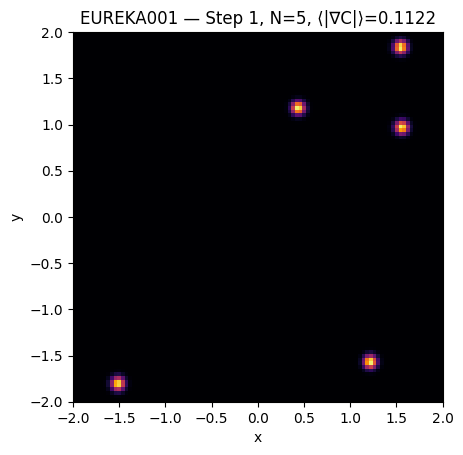

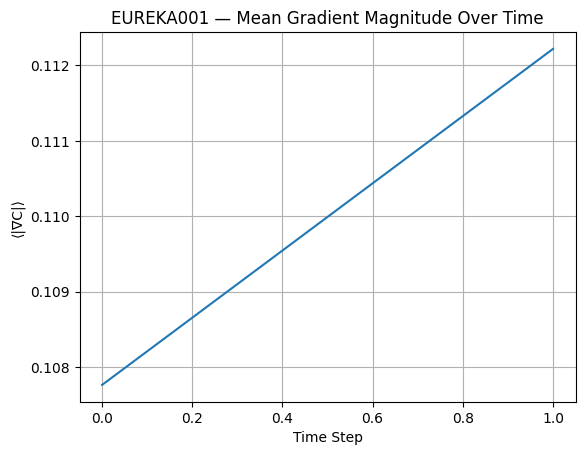

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# === Parameters ===
G = 1.0                  # Gravitational constant (scaled units)
sigma = 0.05             # Width of memory bumps
box_size = 2.0           # Simulation box size
n_steps = 500            # Time steps
dt = 0.01                # Time step size
density_schedule = np.linspace(5, 100, n_steps).astype(int)  # Increasing number of bodies

# === Initialize field grid ===
grid_size = 100
x = np.linspace(-box_size, box_size, grid_size)
y = np.linspace(-box_size, box_size, grid_size)
X, Y = np.meshgrid(x, y)

# === Diagnostics storage ===
grad_mags = []

# === Simulation loop ===
fig, ax = plt.subplots()
field_plot = ax.imshow(np.zeros_like(X), extent=[-box_size, box_size, -box_size, box_size],
                       origin='lower', cmap='inferno', vmin=0, vmax=1)
ax.set_title("EUREKA001 — Curvature Field Evolution")
ax.set_xlabel("x")
ax.set_ylabel("y")

def update(frame):
    N = density_schedule[frame]
    positions = np.random.uniform(-box_size, box_size, size=(N, 2))

    # Build curvature field from memory bumps
    C = np.zeros_like(X)
    for r_i in positions:
        dx = X - r_i[0]
        dy = Y - r_i[1]
        C += np.exp(-(dx**2 + dy**2) / (2 * sigma**2))

    # Normalize and saturate
    C = np.clip(C, 0, 1)

    # Compute gradient magnitude
    dC_dx, dC_dy = np.gradient(C, x, y)
    grad_mag = np.sqrt(dC_dx**2 + dC_dy**2)
    grad_mags.append(np.mean(grad_mag))

    # Update plot
    field_plot.set_data(C)
    ax.set_title(f"EUREKA001 — Step {frame+1}, N={N}, ⟨|∇C|⟩={grad_mags[-1]:.4f}")
    return [field_plot]

ani = FuncAnimation(fig, update, frames=n_steps, interval=50, blit=True)
plt.show()

# === Plot gradient decay
plt.figure()
plt.plot(grad_mags)
plt.title("EUREKA001 — Mean Gradient Magnitude Over Time")
plt.xlabel("Time Step")
plt.ylabel("⟨|∇C|⟩")
plt.grid(True)
plt.show()
